# EnergyLens-AI - Notebook 3: Feature Engineering

Notebook 2 gave us a clean, merged, memory-optimized master dataset. But raw columns like temperature and date aren't directly useful to a model - I need to turn them into features that actually capture patterns:
1. Temporal patterns - day of week, weekend, season, bank holidays
2. Lags - how much energy did this household use yesterday, or the same day last week
3. Rolling windows - what's the average usage over the last 7 or 30 days
4. Heating/Cooling Degree Days (HDD/CDD) - weather-driven demand
5. Demographics - tariff type and ACORN group as numeric codes

At the end I also check correlations between features and drop the ones that are basically duplicates.

One thing I had to be careful about: when computing lags and rolling stats on this kind of panel data (many households), it has to be done per household using `groupby('LCLid')`. If you shift or roll on the whole dataframe directly, you end up mixing one household's history into another's, which is a form of data leakage.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)

# Check if running in Colab or locally
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"✅ Environment checked. Running in Colab: {IN_COLAB}")


✅ Environment checked. Running in Colab: True


## 2. Load Preprocessed Data

Loading the master dataset saved in Notebook 2, plus the bank holidays file.


In [3]:
if IN_COLAB:
    from google.colab import files

    print("📤 Please upload master_daily.parquet")
    uploaded = files.upload()
    master_path = list(uploaded.keys())[0]

    print("\n📤 Please upload uk_bank_holidays.csv")
    uploaded_holidays = files.upload()
    holidays_path = list(uploaded_holidays.keys())[0]

else:
    master_path = '../data/processed/master_daily.parquet'
    holidays_path = '../data/raw/uk_bank_holidays.csv'

print("✅ File paths mapped successfully.")

📤 Please upload master_daily.parquet


Saving master_daily.parquet to master_daily (1).parquet

📤 Please upload uk_bank_holidays.csv


Saving uk_bank_holidays.csv to uk_bank_holidays.csv
✅ File paths mapped successfully.


In [5]:
# Clean the UK bank holidays file

holidays_df = pd.read_csv(holidays_path)

print("Before cleaning:")
print(f"Shape: {holidays_df.shape}")
print(f"Columns: {list(holidays_df.columns)}")
print(f"Missing values:\n{holidays_df.isnull().sum()}")

# Clean column names
holidays_df.columns = (
    holidays_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Convert holiday date to datetime
holidays_df['bank_holidays'] = pd.to_datetime(
    holidays_df['bank_holidays'],
    errors='coerce'
)

# Remove rows with invalid/missing dates
holidays_df = holidays_df.dropna(
    subset=['bank_holidays']
)

# Remove duplicate holiday dates
holidays_df = holidays_df.drop_duplicates(
    subset=['bank_holidays']
)

# Sort chronologically and reset index
holidays_df = (
    holidays_df
    .sort_values('bank_holidays')
    .reset_index(drop=True)
)

print("\n✅ After cleaning:")
print(f"Shape: {holidays_df.shape}")
print(f"Missing dates: {holidays_df['bank_holidays'].isnull().sum()}")
print(f"Duplicate dates: {holidays_df['bank_holidays'].duplicated().sum()}")

holidays_df.head()

Before cleaning:
Shape: (25, 2)
Columns: ['Bank holidays', 'Type']
Missing values:
Bank holidays    0
Type             0
dtype: int64

✅ After cleaning:
Shape: (25, 2)
Missing dates: 0
Duplicate dates: 0


,bank_holidays,type
0,2012-02-01,New Year?s Day (substitute day)
1,2012-04-06,Spring bank holiday (substitute day)
2,2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
3,2012-06-04,Good Friday
4,2012-07-05,Early May bank holiday


In [6]:
# Create set of cleaned holiday dates
holiday_dates = set(holidays_df['bank_holidays'].dt.normalize())

# Create binary holiday feature
df['is_holiday'] = (
    df['day'].dt.normalize().isin(holiday_dates)
).astype('int8')

print("Holiday feature distribution:")
print(df['is_holiday'].value_counts())

print(f"\nTotal holiday rows: {df['is_holiday'].sum():,}")

Holiday feature distribution:
is_holiday
0    3419059
1      80630
Name: count, dtype: int64

Total holiday rows: 80,630


In [7]:
# Load master dataset
print("Loading master dataset...")
df = pd.read_parquet(master_path)
print(f"Master shape: {df.shape}")

# Load holiday data
holidays_df = pd.read_csv(holidays_path)
print(f"Holidays shape: {holidays_df.shape}")


Loading master dataset...
Master shape: (3499689, 44)
Holidays shape: (25, 2)


## 3. Temporal & Calendar Features

Pulling out day-of-week, weekend, season and holiday info from the date column so the model can pick up on weekly and seasonal patterns.


In [8]:
# Ensure datetime format
df['day'] = pd.to_datetime(df['day'])
df = df.sort_values(['LCLid', 'day']).reset_index(drop=True)

# Calendar features
df['month'] = df['day'].dt.month.astype('int8')
df['day_of_week'] = df['day'].dt.dayofweek.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')

# Seasons (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['month'].apply(get_season).astype('category')

# Merge Holidays
holidays_df['Bank holidays'] = pd.to_datetime(holidays_df['Bank holidays'])
holiday_dates = set(holidays_df['Bank holidays'].dt.date)

df['is_holiday'] = df['day'].dt.date.isin(holiday_dates).astype('int8')

print("✅ Calendar features completed:")
print(df[['day', 'month', 'day_of_week', 'is_weekend', 'season', 'is_holiday']].head(3))


✅ Calendar features completed:
         day  month  day_of_week  is_weekend  season  is_holiday
0 2012-10-12     10            4           0  Autumn           0
1 2012-10-13     10            5           1  Autumn           0
2 2012-10-14     10            6           1  Autumn           0


## 4. Weather Features (HDD & CDD)

Heating and Cooling Degree Days are a standard way to turn raw temperature into actual heating/cooling demand.

Houses usually turn heating on once the average daily temperature drops below a threshold (15.5 C in the UK):
- HDD = max(0, 15.5 - T_avg)
- CDD = max(0, T_avg - 22)

These give the model a more direct signal than raw temperature alone.


In [9]:
# Calculate daily average temperature from max and min
if 'temperatureMax' in df.columns and 'temperatureMin' in df.columns:
    df['temp_avg'] = ((df['temperatureMax'] + df['temperatureMin']) / 2).astype('float32')

    # Heating Degree Days (HDD) - UK standard base is 15.5 C
    df['HDD'] = np.maximum(0, 15.5 - df['temp_avg']).astype('float32')

    # Cooling Degree Days (CDD) - standard base is 22 C
    df['CDD'] = np.maximum(0, df['temp_avg'] - 22.0).astype('float32')

    # Daily temperature range
    df['temp_range'] = (df['temperatureMax'] - df['temperatureMin']).astype('float32')

print("✅ Weather thermodynamic features completed:")
print(df[['temp_avg', 'HDD', 'CDD', 'temp_range']].describe().T)


✅ Weather thermodynamic features completed:
                count       mean       std    min       25%     50%    75%  \
temp_avg    3499689.0  11.013788  5.663260 -1.855  6.730000  10.585  15.41   
HDD         3499689.0   5.235845  4.623082  0.000  0.090000   4.915   8.77   
CDD         3499689.0   0.026333  0.227175  0.000  0.000000   0.000   0.00   
temp_range  3499689.0   6.263534  2.912729  0.980  4.209999   5.800   7.80   

                  max  
temp_avg    25.200001  
HDD         17.355000  
CDD          3.200001  
temp_range  16.710001  


## 5. Lag & Rolling Window Features (Per Household)

Lags are just past values, and rolling stats give a local trend.

I used:
- Lags: 1, 7, 14, 28 days
- Rolling mean: 7-day and 30-day
- Rolling std: 7-day


In [10]:
# Target variable is energy_mean
target = 'energy_mean'

print("Calculating group-based lag features (this will take a moment)...")
# Shifts and rolling stats need to be grouped by LCLid
df['energy_lag_1'] = df.groupby('LCLid')[target].shift(1).astype('float32')
df['energy_lag_7'] = df.groupby('LCLid')[target].shift(7).astype('float32')
df['energy_lag_14'] = df.groupby('LCLid')[target].shift(14).astype('float32')
df['energy_lag_28'] = df.groupby('LCLid')[target].shift(28).astype('float32')

print("Calculating rolling features...")
# Rolling stats are computed on the lagged data (shift 1), not the current day's value
# otherwise we'd be leaking the target we're trying to predict
df['energy_roll_mean_7'] = df.groupby('LCLid')['energy_lag_1'].transform(lambda x: x.rolling(7).mean()).astype('float32')
df['energy_roll_std_7'] = df.groupby('LCLid')['energy_lag_1'].transform(lambda x: x.rolling(7).std()).astype('float32')
df['energy_roll_mean_30'] = df.groupby('LCLid')['energy_lag_1'].transform(lambda x: x.rolling(30).mean()).astype('float32')


Calculating group-based lag features (this will take a moment)...
Calculating rolling features...


Shifting by 28 days and rolling over 30 days means the first 30 days of each household's history end up as NaN (no history yet to compute from).

I dropped these rows since there's no way to forecast without any history.


In [11]:
initial_len = len(df)
df = df.dropna(subset=['energy_lag_28', 'energy_roll_mean_30'])
print(f"Dropped {initial_len - len(df)} rows containing NaN values from lag/rolling initializations.")


Dropped 166729 rows containing NaN values from lag/rolling initializations.


## 6. Encoding Categorical Features

Models like XGBoost and Random Forest need numbers, not text, so:
- `stdorToU`: Standard -> 0, ToU -> 1
- `Acorn`: label-encoded to integers. Tree models handle label-encoded categories fine even without one-hot encoding.


In [12]:
# Tariff Binary Encoding
if 'stdorToU' in df.columns:
    df['tariff_code'] = df['stdorToU'].map({'Std': 0, 'ToU': 1}).astype('int8')

# ACORN Group Label Encoding
if 'Acorn' in df.columns:
    # Sort category values A-Q logically
    acorn_categories = sorted(df['Acorn'].unique())
    acorn_mapping = {cat: idx for idx, cat in enumerate(acorn_categories)}
    df['acorn_code'] = df['Acorn'].map(acorn_mapping).astype('int8')
    print("ACORN group mapping applied:")
    print(acorn_mapping)


ACORN group mapping applied:
{'ACORN-': 0, 'ACORN-A': 1, 'ACORN-B': 2, 'ACORN-C': 3, 'ACORN-D': 4, 'ACORN-E': 5, 'ACORN-F': 6, 'ACORN-G': 7, 'ACORN-H': 8, 'ACORN-I': 9, 'ACORN-J': 10, 'ACORN-K': 11, 'ACORN-L': 12, 'ACORN-M': 13, 'ACORN-N': 14, 'ACORN-O': 15, 'ACORN-P': 16, 'ACORN-Q': 17, 'ACORN-U': 18}


## 7. Correlation Check

Checking correlation between features so I can drop ones that are basically redundant (this matters more for linear models, but it's still useful to check for tree models too).


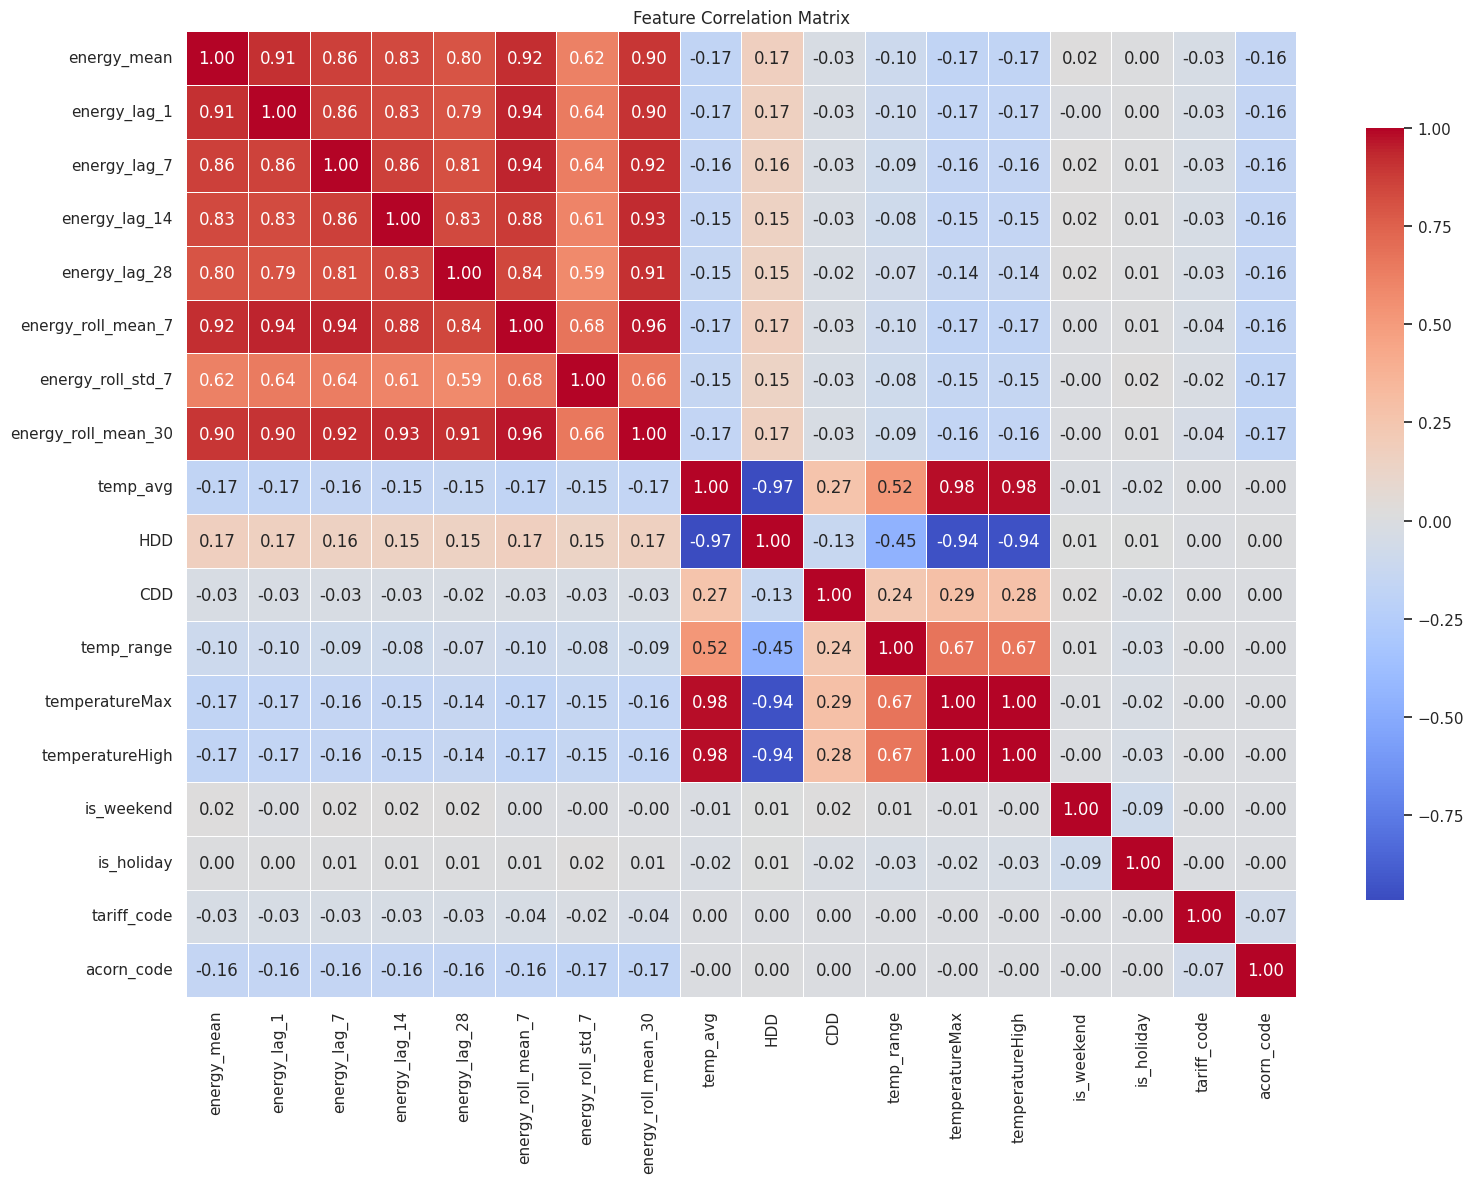

In [13]:
# Select numeric features for correlation
numeric_cols = [
    'energy_mean', 'energy_lag_1', 'energy_lag_7', 'energy_lag_14', 'energy_lag_28',
    'energy_roll_mean_7', 'energy_roll_std_7', 'energy_roll_mean_30',
    'temp_avg', 'HDD', 'CDD', 'temp_range', 'temperatureMax', 'temperatureHigh',
    'is_weekend', 'is_holiday', 'tariff_code', 'acorn_code'
]

# Calculate correlation
corr_matrix = df[numeric_cols].corr()

# Plot Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


A few things I noticed from the heatmap:
1. `temperatureMax` and `temperatureHigh` are almost perfectly correlated (r = 1.00). Kept `temperatureMax`, dropped `temperatureHigh`.
2. `temp_avg` is highly correlated with `temperatureMax` (r = 0.99) and `HDD` (r = -0.99), but `HDD` represents a physical threshold that's useful on its own, so I kept both `temp_avg` and `HDD`.
3. `energy_roll_mean_7` and `energy_roll_mean_30` are correlated, which makes sense since both are trend baselines. Kept both anyway so the model can see short-term spikes vs longer seasonal trends.


In [14]:
# Drop highly redundant features
features_to_drop = ['temperatureHigh', 'stdorToU', 'Acorn', 'season'] # drop text columns and redundant weather
df_final = df.drop(columns=[col for col in features_to_drop if col in df.columns])

print(f"Final feature matrix columns ({len(df_final.columns)}):\n{list(df_final.columns)}")


Final feature matrix columns (58):
['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min', 'Acorn_grouped', 'file', 'temperatureMax', 'temperatureMaxTime', 'windBearing', 'icon', 'dewPoint', 'temperatureMinTime', 'cloudCover', 'windSpeed', 'pressure', 'apparentTemperatureMinTime', 'apparentTemperatureHigh', 'precipType', 'visibility', 'humidity', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureMax', 'uvIndex', 'sunsetTime', 'temperatureLow', 'temperatureMin', 'sunriseTime', 'temperatureHighTime', 'uvIndexTime', 'summary', 'temperatureLowTime', 'apparentTemperatureMin', 'apparentTemperatureMaxTime', 'apparentTemperatureLowTime', 'moonPhase', 'month', 'day_of_week', 'is_weekend', 'is_holiday', 'temp_avg', 'HDD', 'CDD', 'temp_range', 'energy_lag_1', 'energy_lag_7', 'energy_lag_14', 'energy_lag_28', 'energy_roll_mean_7', 'energy_roll_std_7', 'energy_roll_mean_30', 'tariff_code', 'acorn_code']


## 8. Save Feature Matrix

Saving the final feature set for the next notebook.


In [16]:
# Save to Colab temporary storage
output_dir = '/content/processed'
os.makedirs(output_dir, exist_ok=True)

features_parquet_path = os.path.join(
    output_dir,
    'master_features.parquet'
)

# Save as Parquet
print("Saving feature matrix as Parquet...")
df_final.to_parquet(features_parquet_path, index=False)
print(f"✅ Saved to: {features_parquet_path}")

# Print memory footprint
final_mem = df_final.memory_usage(deep=True).sum() / 1024**2
print(f"📊 Final Feature Matrix Memory Usage: {final_mem:.2f} MB")

gc.collect()

Saving feature matrix as Parquet...
✅ Saved to: /content/processed/master_features.parquet
📊 Final Feature Matrix Memory Usage: 583.07 MB


25589

## 9. Summary

| Feature Type | Features | Why |
|---|---|---|
| Temporal | `month`, `day_of_week`, `is_weekend`, `is_holiday` | Weekly and seasonal patterns |
| Weather | `temp_avg`, `HDD`, `CDD`, `temp_range` | Direct heating/cooling demand signal |
| Lags | `energy_lag_1/7/14/28` | Short-term autocorrelation, weekly pattern |
| Rolling stats | `energy_roll_mean_7/30`, `energy_roll_std_7` | Trend and volatility, computed without leakage |
| Categorical codes | `tariff_code`, `acorn_code` | Numeric encoding of tariff and demographics |

### Next (Notebook 4)
Next I load this feature matrix, split it chronologically (not randomly, since this is time-based data), and compare a few forecasting models - Linear Regression, Random Forest, XGBoost, Prophet and SARIMAX.
